Dane załadowane. Przykład pierwszych 5 wierszy:
   time   S   Z  R  I
0     1  79  36  2  0
1     2  79  36  2  2
2     3  78  35  3  3
3     4  77  35  3  5
4     5  76  34  4  6
Trwa obliczanie parametrów modelu...

ZNALEZIONE PARAMETRY (Dopasowane):
Beta   (Atak):        0.04268
Delta  (Leczenie):    0.39854
--- Parametry stałe ---
Rho    (Inkubacja):   0.05000
Lambda (Narodziny):   0.00200

KLASA      | RMSE (błąd śr.) | R2 (dopasowanie)
----------------------------------------------
S          | 13.4272         | 0.9911         
I          | 4.4785          | -0.4345        
Z          | 28.9486         | -16.6317       
R          | 24.4863         | -5.5777        
----------------------------------------------


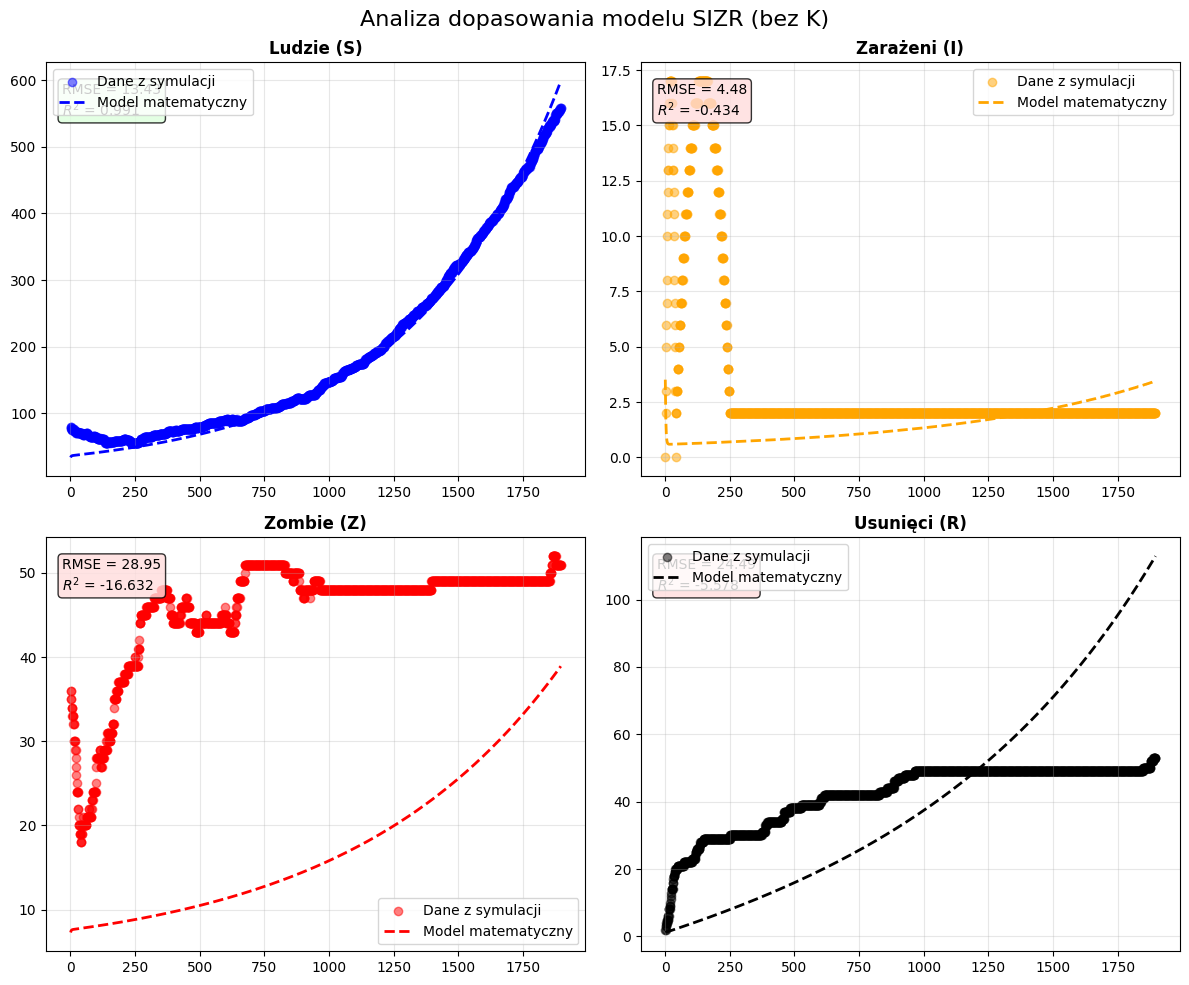

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# 1. PRZYGOTOWANIE DANYCH
# ==========================================
# Zastąp to wczytaniem swojego CSV
df = pd.read_csv('../populacja6_z_I.csv')

print("Dane załadowane. Przykład pierwszych 5 wierszy:")
print(df.head())

t_data = df['time'].to_numpy(dtype=float)
S_data = df['S'].to_numpy(dtype=float)
I_data = df['I'].to_numpy(dtype=float) # Upewnij się, że masz tę kolumnę!
Z_data = df['Z'].to_numpy(dtype=float)
R_data = df['R'].to_numpy(dtype=float)

# Warunki początkowe
y0 = [S_data[0], I_data[0], Z_data[500], R_data[0]]

# Spłaszczamy dane
y_data_flat = np.concatenate([S_data, I_data, Z_data, R_data])

# Wpisz tu wartości, które masz "na sztywno" w symulacji
KNOWN_LAMBDA = 0.002   # Twoje 2 promile
# Jeśli cooldown infekcji to np. 20 klatek, to Rho = 1/20 = 0.05
KNOWN_RHO    = 0.05
KNOWN_GAMMA  = 1.0 / 300.0  # 1/300 (Śmierć z głodu)

def model_sizr_fixed(t, y, beta, delta):
    """
    Model przyjmuje tylko 3 zmienne do optymalizacji.
    Lambda i Rho są brane z góry (globalne stałe).
    """
    S, I, Z, R = y
    N = S + I + Z
    if N < 1e-9: N = 1.0 

    # Używamy WSZYSTKICH trzech stałych
    dS = -beta * (S * Z / N) + delta * I + KNOWN_LAMBDA * S
    dI = beta * (S * Z / N) - KNOWN_RHO * I - delta * I
    
    # dZ zależy od stałego Rho i stałego Gamma
    dZ = KNOWN_RHO * I - KNOWN_GAMMA * Z
    dR = KNOWN_GAMMA * Z
    
    return [dS, dI, dZ, dR]

# Wrapper do curve_fit
def fit_wrapper(t, beta, delta, S0, I0, Z0, R0):
    y0_opt = [S0, I0, Z0, R0]
    
    sol = solve_ivp(
        lambda tt, yy: model_sizr_fixed(tt, yy, beta, delta),
        [t[0], t[-1]], y0_opt, t_eval=t, rtol=1e-5, method='LSODA'
    )
    
    if not sol.success or sol.y.shape[1] != len(t):
        return np.zeros(len(t) * 4)
    return sol.y.flatten()
    
p0_guess = [0.5, 0.1, S_data[0], I_data[0], Z_data[0], R_data[0]]

print("Trwa obliczanie parametrów modelu...")
try:
    popt, pcov = curve_fit(
        fit_wrapper, t_data, y_data_flat, 
        p0=p0_guess, 
        bounds=(0, np.inf), 
        method='trf',
        maxfev=10000
    )
    # Rozpakowujemy tylko to, co szukaliśmy
    beta_fit, delta_fit, S0_fit, I0_fit, Z0_fit, R0_fit = popt
except Exception as e:
    print(f"Błąd: {e}")
    exit()

print("\n" + "="*40)
print(f"ZNALEZIONE PARAMETRY (Dopasowane):")
print(f"Beta   (Atak):        {beta_fit:.5f}")
print(f"Delta  (Leczenie):    {delta_fit:.5f}")
# print(f"Gamma  (Śmierć):      {gamma_fit:.5f}")
print(f"--- Parametry stałe ---")
print(f"Rho    (Inkubacja):   {KNOWN_RHO:.5f}")
print(f"Lambda (Narodziny):   {KNOWN_LAMBDA:.5f}")
print("="*40 + "\n")

# ==========================================
# 4. OBLICZANIE STATYSTYK (RMSE i R2) PER KLASA
# ==========================================
# Generujemy krzywe idealne wg modelu
y0_best = [S0_fit, I0_fit, Z0_fit, R0_fit]

sol_final = solve_ivp(
    lambda tt, yy: model_sizr_fixed(tt, yy, beta_fit, delta_fit),
    [t_data[0], t_data[-1]], y0_best, t_eval=t_data
)
S_pred, I_pred, Z_pred, R_pred = sol_final.y

def get_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

metrics = {
    "S": get_metrics(S_data, S_pred),
    "I": get_metrics(I_data, I_pred),
    "Z": get_metrics(Z_data, Z_pred),
    "R": get_metrics(R_data, R_pred)
}

# Wyświetlenie tabelki w konsoli
print(f"{'KLASA':<10} | {'RMSE (błąd śr.)':<15} | {'R2 (dopasowanie)':<15}")
print("-" * 46)
for cls, (rmse, r2) in metrics.items():
    print(f"{cls:<10} | {rmse:<15.4f} | {r2:<15.4f}")
print("-" * 46)

# ==========================================
# 5. GENEROWANIE WYKRESÓW
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Analiza dopasowania modelu SIZR (bez K)', fontsize=16)

# Definicje do pętli rysującej
plots_config = [
    (axs[0,0], t_data, S_data, S_pred, 'Ludzie (S)', 'blue', metrics['S']),
    (axs[0,1], t_data, I_data, I_pred, 'Zarażeni (I)', 'orange', metrics['I']),
    (axs[1,0], t_data, Z_data, Z_pred, 'Zombie (Z)', 'red', metrics['Z']),
    (axs[1,1], t_data, R_data, R_pred, 'Usunięci (R)', 'black', metrics['R'])
]

for ax, t, data, pred, title, color, (rmse, r2) in plots_config:
    # Rysowanie danych i modelu
    ax.scatter(t, data, alpha=0.5, color=color, label='Dane z symulacji')
    ax.plot(t, pred, color=color, linewidth=2, linestyle='--', label='Model matematyczny')
    
    # Tytuł i legenda
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Wypisanie statystyk NA wykresie (w ramce)
    stats_text = f"RMSE = {rmse:.2f}\n$R^2$ = {r2:.3f}"
    # Kolor tła ramki: zielony jak R2 dobre, czerwony jak słabe
    bg_color = '#ddffdd' if r2 > 0.8 else '#ffdddd'
    
    ax.text(0.03, 0.95, stats_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor=bg_color, alpha=0.8))

plt.tight_layout()
plt.show()